# Proyecto Final — Fundamentos de Ciencia de Datos

# **Inicio del Análisis Exploratorio de Datos (EDA)**

In [1]:
#Carga de librerías y conjunto de datos

import os
import warnings
import math

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Descarga de la última versión del dataset
path = kagglehub.dataset_download("sonalshinde123/work-from-home-employee-burnout-dataset")
csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
full_path = os.path.join(path, csv_file)

df_raw = pd.read_csv(full_path)

print(f"Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}")
print("Columnas:", df_raw.columns.tolist())
display(df_raw.head())

Using Colab cache for faster access to the 'work-from-home-employee-burnout-dataset' dataset.
Filas: 1800 | Columnas: 11
Columnas: ['user_id', 'day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate', 'burnout_score', 'burnout_risk']


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


## 1. Revisión inicial y valores nulos

Primero se identifican las columnas clave y se verifica si existen datos faltantes.

La variable identificadora `user_id` se excluye de todos los cálculos descriptivos porque no representa una característica analítica.

In [2]:
target_col = "burnout_risk"
id_cols = [c for c in df_raw.columns if c.lower() in {"id", "user_id"}]

# Copia de trabajo sin identificadores
df_working = df_raw.drop(columns=id_cols, errors="ignore").copy()

# Variables numéricas principales para el EDA
aux_numeric_cols = [c for c in ["burnout_score"] if c in df_working.columns]
numeric_cols = [
    c for c in df_working.select_dtypes(include=np.number).columns
    if c not in [target_col] + aux_numeric_cols
]

# Variables categóricas principales
categorical_cols = [
    c for c in df_working.columns
    if c not in numeric_cols + aux_numeric_cols + [target_col]
    and not pd.api.types.is_numeric_dtype(df_working[c])
]

print("Columnas identificadoras excluidas:", id_cols)
print("Variables numéricas principales:", numeric_cols)
print("Variables numéricas auxiliares:", aux_numeric_cols)
print("Variables categóricas:", categorical_cols)

print("\nValores faltantes por columna (dataset bruto):")
display(df_raw.isna().sum().to_frame("nulos"))

print("\nValores faltantes por columna (dataset de trabajo, sin identificadores):")
display(df_working.isna().sum().to_frame("nulos"))

print("\nDuplicados exactos en el dataset bruto:")
print(df_raw.duplicated().sum())

print("\nDistribución original del nivel de riesgo:")
display((df_working[target_col].value_counts(normalize=True) * 100).round(2).to_frame("porcentaje"))

Columnas identificadoras excluidas: ['user_id']
Variables numéricas principales: ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate']
Variables numéricas auxiliares: ['burnout_score']
Variables categóricas: ['day_type']

Valores faltantes por columna (dataset bruto):


,nulos
user_id,0
day_type,0
work_hours,0
screen_time_hours,0
meetings_count,0
breaks_taken,0
after_hours_work,0
sleep_hours,0
task_completion_rate,0
burnout_score,0



Valores faltantes por columna (dataset de trabajo, sin identificadores):


,nulos
day_type,0
work_hours,0
screen_time_hours,0
meetings_count,0
breaks_taken,0
after_hours_work,0
sleep_hours,0
task_completion_rate,0
burnout_score,0
burnout_risk,0



Duplicados exactos en el dataset bruto:
0

Distribución original del nivel de riesgo:


,porcentaje
burnout_risk,
Low,84.83
Medium,14.06
High,1.11


**Análisis:** No se encuentran valores nulos en el dataset por lo que no es necesario imputar datos, pero si se identifica un desbalance en la distribución de la variable burnout_risk (variable objetivo), por lo que va a ser necesario realizar un balanceo en el dataset.

**Unificación de categorías** es una estrategia muy común en ciencia de datos para resolver problemas de desbalanceo.
Al agrupar "Medio" y "Alto", se transforma un problema de una clasificación multiclase (Bajo, Medio, Alto) a una clasificación binaria (Sin Riesgo vs. En Riesgo).

In [3]:
# Se crea una copia para no alterar los datos anteriores
df_binario = df_raw.copy()

# Mapeamos las categorías actuales a la nueva estructura binaria
mapeo = {
    'Low': 'Sin_Riesgo',
    'Medium': 'En_Riesgo',
    'High': 'En_Riesgo'
}

# Aplicamos el cambio en la columna objetivo
df_binario[target_col] = df_binario[target_col].map(mapeo)

# Verificamos cómo quedó la nueva distribución
print("Nueva distribución binaria del riesgo:")
display((df_binario[target_col].value_counts(normalize=True) * 100).round(2).to_frame("porcentaje"))

Nueva distribución binaria del riesgo:


,porcentaje
burnout_risk,
Sin_Riesgo,84.83
En_Riesgo,15.17


**Métodos basados en la modificación de los datos**

Modifican la distribución de clases mediante técnicas de sobremuestreo, submuestreo o generación sintética de instancias, buscando equilibrar la representación de cada clase.

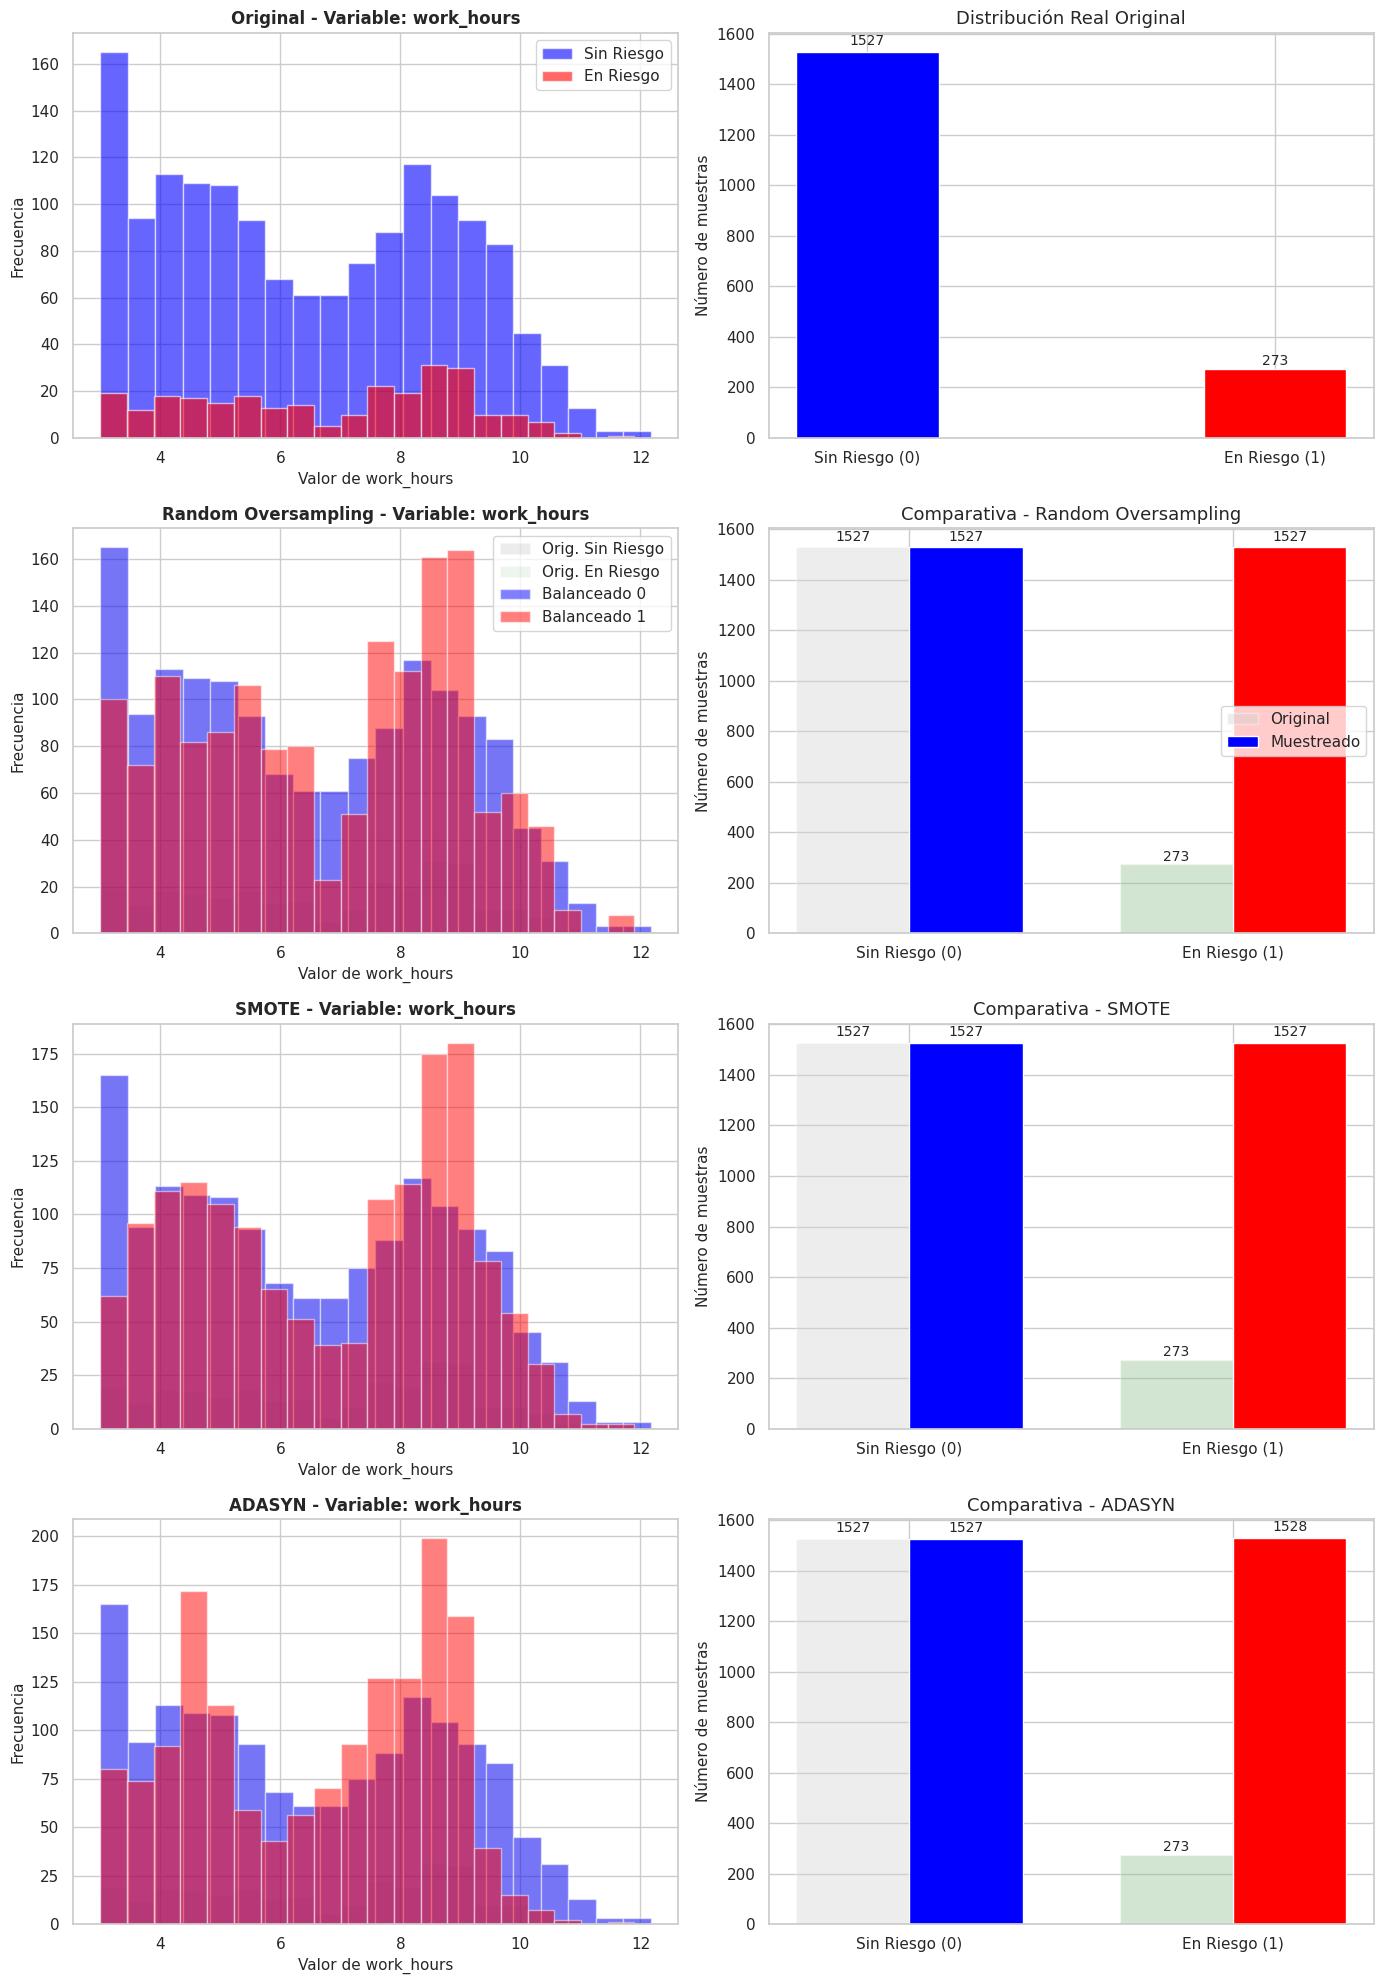

In [4]:

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Variable objetivo unificada (Binaria: 'Sin_Riesgo' --> 0 vs 'En_Riesgo' --> 1)
# Convertimos a 0 y 1 para que los métodos de sobremuestreo funcionen sin problemas
y_data = df_working[target_col].map({'Low': 0, 'Medium': 1, 'High': 1})
X_data = df_working.drop(columns=target_col, errors='ignore')

# Aplicar One-Hot Encoding a las columnas categóricas
# Se identificó en el EDA que 'day_type' es la única columna categórica
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)
X_data_encoded = preprocessor.fit_transform(X_data)

# Si quedaron filas con nulos en el target después del mapeo, las eliminamos en ambos
valid_idx = y_data.dropna().index
X_real = X_data_encoded[valid_idx]
y_real = y_data.loc[valid_idx].values

# Obtenemos los nombres de las columnas transformadas para encontrar el índice correcto de 'work_hours'
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
remaining_feature_names = [col for col in X_data.columns if col not in categorical_cols and col != target_col]
all_feature_names = encoded_feature_names + remaining_feature_names

# Encontrar el índice de 'work_hours' en las columnas transformadas
feature_name = 'work_hours'
feature_idx = all_feature_names.index(feature_name)

original_counts = [np.sum(y_real == 0), np.sum(y_real == 1)]

# Aplicamos técnicas de submuestreo
methods = {
    'Random Oversampling': RandomOverSampler(random_state=42).fit_resample(X_real, y_real),
    'SMOTE': SMOTE(random_state=42).fit_resample(X_real, y_real),
    'ADASYN': ADASYN(random_state=42).fit_resample(X_real, y_real)
}

fig, axes = plt.subplots(len(methods) + 1, 2, figsize=(14, 20))

bar_labels = ['Sin Riesgo (0)', 'En Riesgo (1)']
x_pos = np.arange(len(bar_labels))
width = 0.35

axes[0, 0].set_title(f'Original - Variable: {feature_name}', fontsize=12, fontweight='bold')
axes[0, 0].hist(X_real[y_real == 0, feature_idx], bins=20, color='blue', alpha=0.6, label='Sin Riesgo')
axes[0, 0].hist(X_real[y_real == 1, feature_idx], bins=20, color='red', alpha=0.6, label='En Riesgo')
axes[0, 0].set_xlabel(f'Valor de {feature_name}')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

bars = axes[0, 1].bar(x_pos, original_counts, width, color=['blue', 'red'])
axes[0, 1].set_ylabel('Número de muestras')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(bar_labels)
axes[0, 1].set_title('Distribución Real Original')

for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, height + (height * 0.01), f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)

for i, (name, (X_res, y_res)) in enumerate(methods.items(), start=1):
    axes[i, 0].set_title(f'{name} - Variable: {feature_name}', fontsize=12, fontweight='bold')

    axes[i, 0].hist(X_real[y_real == 0, feature_idx], bins=20, color='gray', alpha=0.15, label='Orig. Sin Riesgo')
    axes[i, 0].hist(X_real[y_real == 1, feature_idx], bins=20, color='darkseagreen', alpha=0.15, label='Orig. En Riesgo')

    axes[i, 0].hist(X_res[y_res == 0, feature_idx], bins=20, color='blue', alpha=0.5, label='Balanceado 0')
    axes[i, 0].hist(X_res[y_res == 1, feature_idx], bins=20, color='red', alpha=0.5, label='Balanceado 1')
    axes[i, 0].set_xlabel(f'Valor de {feature_name}')
    axes[i, 0].set_ylabel('Frecuencia')
    if i == 1:
        axes[i, 0].legend()

    # Gráfico de barras comparativo
    current_counts = [np.sum(y_res == 0), np.sum(y_res == 1)]
    bars1 = axes[i, 1].bar(x_pos - width/2, original_counts, width, label='Original', color=['lightgray','darkseagreen'], alpha=0.4)
    bars2 = axes[i, 1].bar(x_pos + width/2, current_counts, width, label='Muestreado', color=['blue', 'red'])

    axes[i, 1].set_ylabel('Número de muestras')
    axes[i, 1].set_xticks(x_pos)
    axes[i, 1].set_xticklabels(bar_labels)
    axes[i, 1].set_title(f'Comparativa - {name}')
    if i == 1:
        axes[i, 1].legend()

    for bar in list(bars1) + list(bars2):
        height = bar.get_height()
        axes[i, 1].text(bar.get_x() + bar.get_width() / 2, height + (height * 0.01), f'{int(height)}',
                        ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Evaluación de los métodos de desbalanceo**

Para evaluar y comparar los tres métodos de sobremuestreo (Random Oversampling, SMOTE y ADASYN), se necesita medir cómo impactan en el rendimiento del clasificador final (la Regresión Logística).

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Separamos los datos originales. El test_size mantiene el desbalance real.
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42, stratify=y_real
)

# Escalador (ajustado con los datos de entrenamiento)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test_orig) # El set de prueba se queda estático

reporte_desbalanceo = []

# Re-instanciamos los métodos para aplicarlos estrictamente al set de entrenamiento
metodos_eval = {
    'Random Oversampling': RandomOverSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42)
}

for nombre, algoritmo in metodos_eval.items():
    # A) Aplicar sobremuestreo SÓLO al set de entrenamiento
    X_train_res, y_train_res = algoritmo.fit_resample(X_train_orig, y_train_orig)

    # B) Escalar el nuevo set de entrenamiento balanceado
    X_train_scaled = scaler.transform(X_train_res)

    # C) Entrenar Regresión Logística
    model = LogisticRegression(random_state=42, max_iter=1000)
    model.fit(X_train_scaled, y_train_res)

    # D) Predecir sobre el set de prueba original (desbalanceado)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # E) Registrar métricas enfocadas en la clase 1 (En Riesgo)
    reporte_desbalanceo.append({
        'Método': nombre,
        'Precision (En Riesgo)': precision_score(y_test_orig, y_pred),
        'Recall (En Riesgo)': recall_score(y_test_orig, y_pred),
        'F1-Score (En Riesgo)': f1_score(y_test_orig, y_pred),
        'ROC-AUC': roc_auc_score(y_test_orig, y_proba)
    })

df_metricas = pd.DataFrame(reporte_desbalanceo).set_index('Método')
print("==== METRICAS DE EVALUACIÓN PARA MÉTODOS DE SOBREMUESTREO ====")
display(df_metricas.round(4))

==== METRICAS DE EVALUACIÓN PARA MÉTODOS DE SOBREMUESTREO ====


,Precision (En Riesgo),Recall (En Riesgo),F1-Score (En Riesgo),ROC-AUC
Método,,,,
Random Oversampling,0.8462,1.0,0.9167,0.9996
SMOTE,0.8462,1.0,0.9167,0.9995
ADASYN,0.8088,1.0,0.8943,1.0000


**Métodos híbridos**

Los métodos híbridos (Borderline-SMOTE, SMOTE+ENN) combinan sobremuestreo y submuestreo para aprovechar las ventajas de ambos enfoques, reduciendo la redundancia de datos sintéticos y el riesgo de pérdida de información.

Se realiza la comparación.

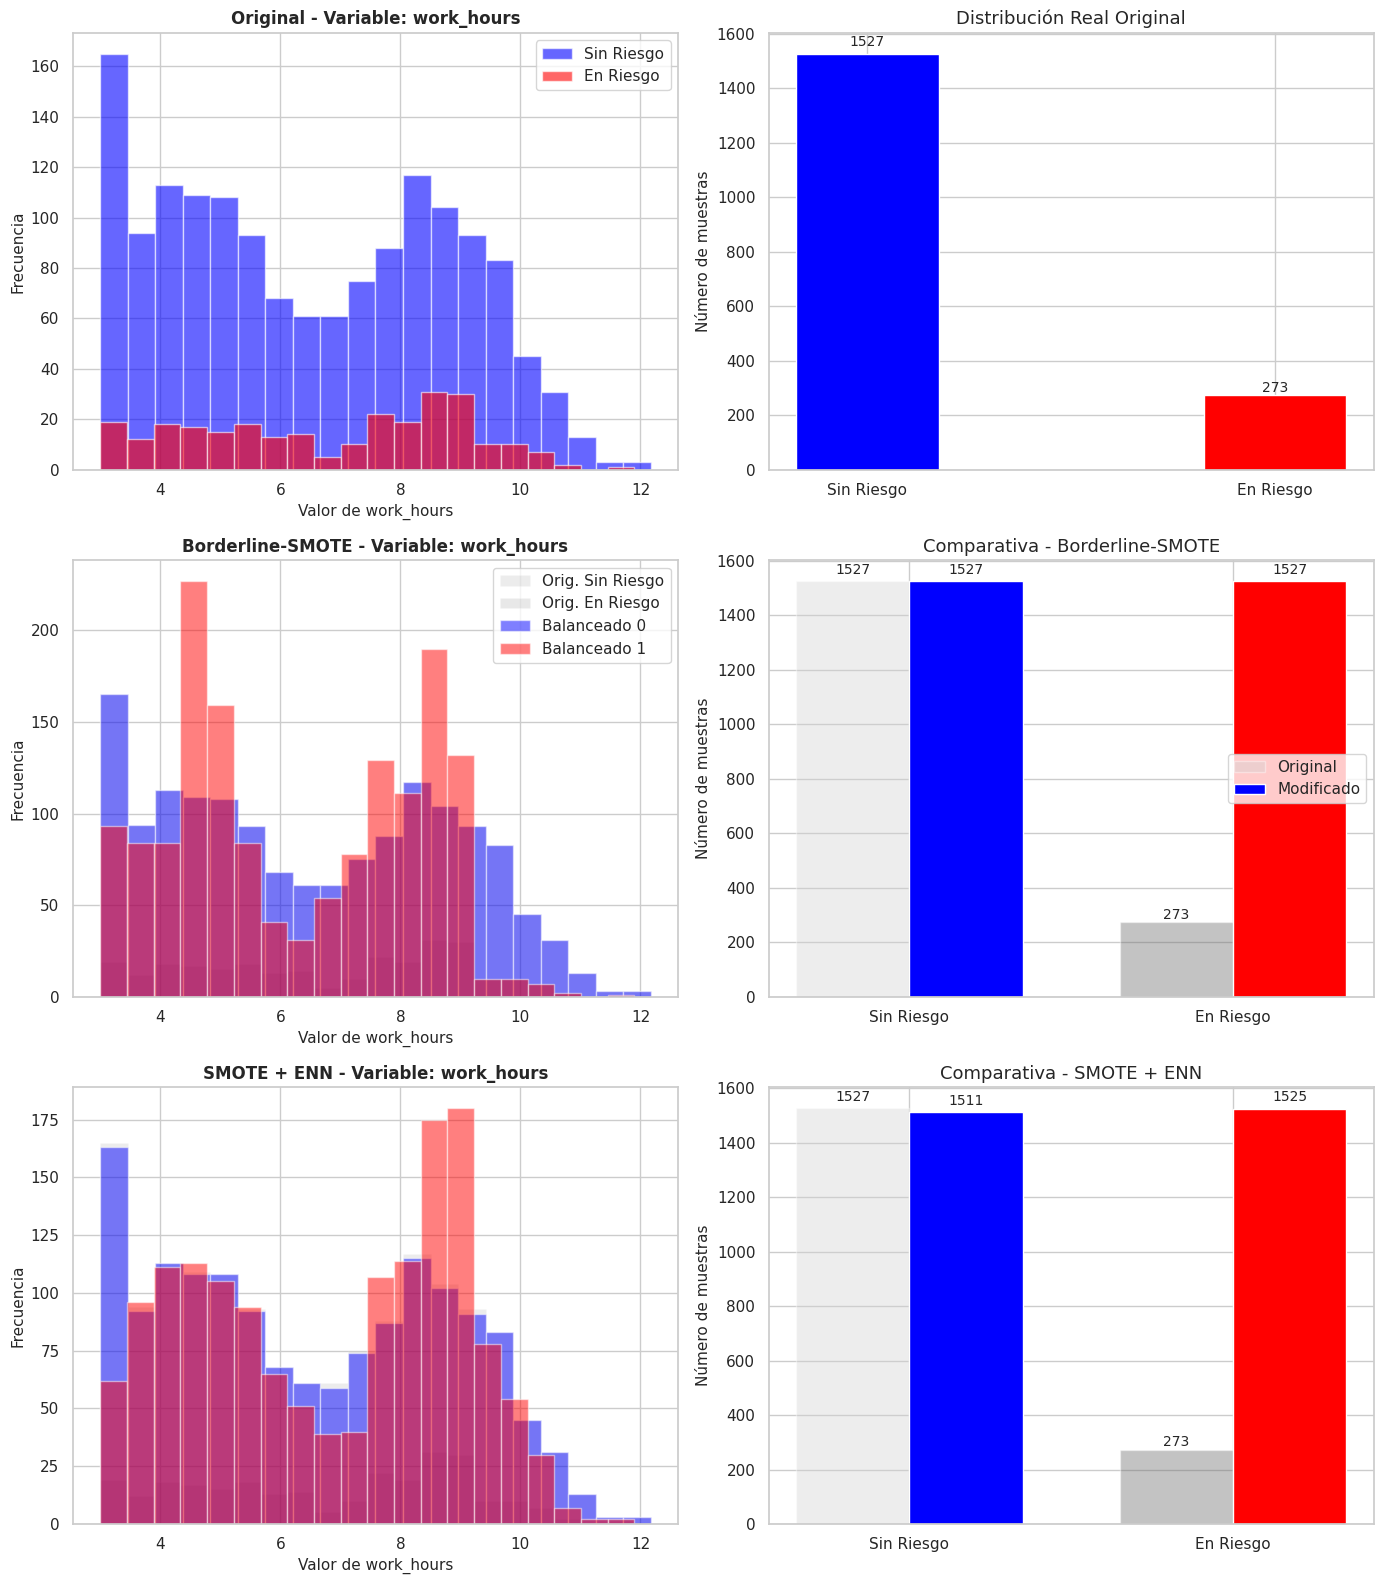

In [6]:

from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTEENN
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Mapeo binario estricto (0: Sin Riesgo, 1: En Riesgo)
y_data = df_working[target_col].map({'Low': 0, 'Medium': 1, 'High': 1})
X_data = df_working.drop(columns=target_col, errors='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)
X_data_encoded = preprocessor.fit_transform(X_data)

# Limpieza de índices por si quedaron nulos en el target mapeado
valid_idx = y_data.dropna().index
X_real = X_data_encoded[valid_idx]
y_real = y_data.loc[valid_idx].values

# Obtenemos los nombres de las columnas transformadas para encontrar el índice correcto de 'work_hours'
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
remaining_feature_names = [col for col in X_data.columns if col not in categorical_cols and col != target_col]
all_feature_names = encoded_feature_names + remaining_feature_names

# Encontrar el índice de 'work_hours' en las columnas transformadas
feature_name = 'work_hours'
feature_idx = all_feature_names.index(feature_name)

original_counts = [np.sum(y_real == 0), np.sum(y_real == 1)]

methods = {
    'Borderline-SMOTE': BorderlineSMOTE(kind='borderline-1', random_state=42).fit_resample(X_real, y_real),
    'SMOTE + ENN': SMOTEENN(random_state=42).fit_resample(X_real, y_real)
}

fig, axes = plt.subplots(len(methods) + 1, 2, figsize=(14, 16))

bar_labels = ['Sin Riesgo', 'En Riesgo']
x_pos = np.arange(len(bar_labels))
width = 0.35

axes[0, 0].set_title(f'Original - Variable: {feature_name}', fontsize=12, fontweight='bold')
axes[0, 0].hist(X_real[y_real == 0, feature_idx], bins=20, color='blue', alpha=0.6, label='Sin Riesgo')
axes[0, 0].hist(X_real[y_real == 1, feature_idx], bins=20, color='red', alpha=0.6, label='En Riesgo')
axes[0, 0].set_xlabel(f'Valor de {feature_name}')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

bars = axes[0, 1].bar(x_pos, original_counts, width, color=['blue', 'red'])
axes[0, 1].set_ylabel('Número de muestras')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(bar_labels)
axes[0, 1].set_title('Distribución Real Original')

for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, height + (height * 0.01), f'{int(height)}',
                    ha='center', va='bottom', fontsize=10)

for i, (name, (X_res, y_res)) in enumerate(methods.items(), start=1):
    axes[i, 0].set_title(f'{name} - Variable: {feature_name}', fontsize=12, fontweight='bold')

    axes[i, 0].hist(X_real[y_real == 0, feature_idx], bins=20, color='gray', alpha=0.15, label='Orig. Sin Riesgo')
    axes[i, 0].hist(X_real[y_real == 1, feature_idx], bins=20, color='dimgray', alpha=0.15, label='Orig. En Riesgo')

    axes[i, 0].hist(X_res[y_res == 0, feature_idx], bins=20, color='blue', alpha=0.5, label='Balanceado 0')
    axes[i, 0].hist(X_res[y_res == 1, feature_idx], bins=20, color='red', alpha=0.5, label='Balanceado 1')
    axes[i, 0].set_xlabel(f'Valor de {feature_name}')
    axes[i, 0].set_ylabel('Frecuencia')
    if i == 1:
        axes[i, 0].legend()

    # Gráfico de barras comparativo
    current_counts = [np.sum(y_res == 0), np.sum(y_res == 1)]
    bars1 = axes[i, 1].bar(x_pos - width/2, original_counts, width, label='Original', color=['lightgray','dimgray'], alpha=0.4)
    bars2 = axes[i, 1].bar(x_pos + width/2, current_counts, width, label='Modificado', color=['blue', 'red'])

    axes[i, 1].set_ylabel('Número de muestras')
    axes[i, 1].set_xticks(x_pos)
    axes[i, 1].set_xticklabels(bar_labels)
    axes[i, 1].set_title(f'Comparativa - {name}')
    if i == 1:
        axes[i, 1].legend()

    for bar in list(bars1) + list(bars2):
        height = bar.get_height()
        axes[i, 1].text(bar.get_x() + bar.get_width() / 2, height + (height * 0.01), f'{int(height)}',
                        ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

**Evaluación de los métodos de desbalanceo híbridos**

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

resultados = []

# Iteramos sobre cada dataset balanceado que guardamos en la celda del terminal oscurecido
for nombre_metodo, (X_res, y_res) in methods.items():

    # Split y Escalado
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # Modelo
    model = LogisticRegression(random_state=42)
    model.fit(X_train_s, y_train)

    # Predicciones
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]

    # Guardar métricas enfocadas en la clase 1 (En Riesgo)
    resultados.append({
        'Método Desbalanceo': nombre_metodo,
        'Precision (En Riesgo)': precision_score(y_test, y_pred),
        'Recall (En Riesgo)': recall_score(y_test, y_pred),
        'F1-Score (En Riesgo)': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

# Convertimos a DataFrame para comparar de un vistazo
df_comparativa = pd.DataFrame(resultados).set_index('Método Desbalanceo')
display(df_comparativa.round(4))

,Precision (En Riesgo),Recall (En Riesgo),F1-Score (En Riesgo),ROC-AUC
Método Desbalanceo,,,,
Borderline-SMOTE,0.9621,1.0000,0.9807,0.9999
SMOTE + ENN,0.9870,0.9967,0.9918,0.9999


**Método Elegido: SMOTE + ENN**

El enfoque híbrido de sobremuestreo y limpieza de ruido (undersampling del ruido) optimizó la frontera de decisión, permitiendo que la Regresión Logística alcance un F1-Score superior al 99% en la detección de empleados en riesgo de burnout.

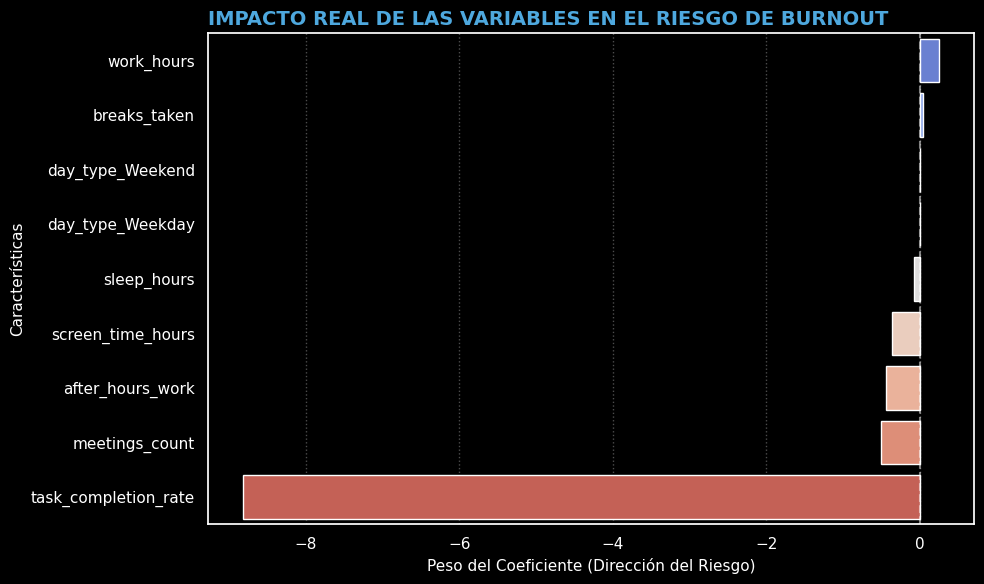


--- Tabla de Coeficientes Ordenada (Sin Burnout Score) ---


,Característica,Impacto (Coeficiente)
2,work_hours,0.2544
5,breaks_taken,0.0405
1,day_type_Weekend,0.0001
0,day_type_Weekday,-0.0001
7,sleep_hours,-0.0748
3,screen_time_hours,-0.3540
6,after_hours_work,-0.4431
4,meetings_count,-0.5093
8,task_completion_rate,-8.8199


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from imblearn.combine import SMOTEENN

# Variable objetivo unificada (Binaria: 'Sin_Riesgo' vs 'En_Riesgo')
y_data = df_working[target_col].map({'Low': 0, 'Medium': 1, 'High': 1})

#Eliminamos también 'burnout_score' de X_data para evitar Data Leakage
X_data = df_working.drop(columns=[target_col, 'burnout_score'], errors='ignore')

# Aplicar One-Hot Encoding a las columnas categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)
X_data_encoded = preprocessor.fit_transform(X_data)

# Limpieza de índices por si quedaron nulos en el target mapeado
valid_idx = y_data.dropna().index
X_real = X_data_encoded[valid_idx]
y_real = y_data.loc[valid_idx].values

# Obtenemos los nombres de las columnas transformadas para los coeficientes
encoded_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

#Nos aseguramos de que 'burnout_score' tampoco se intente mapear en los nombres !!!
remaining_feature_names = [col for col in X_data.columns if col not in categorical_cols and col not in [target_col, 'burnout_score']]
all_feature_names = encoded_feature_names + remaining_feature_names

# Re-crear 'methods' para asegurar que 'burnout_score' no esté en X_real
methods_recreated = {
    'SMOTE + ENN': SMOTEENN(random_state=42).fit_resample(X_real, y_real)
}

X_final, y_final = methods_recreated['SMOTE + ENN']

# Split y Escalado
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Entrenamos la Regresión Logística Final
model_final = LogisticRegression(random_state=42, max_iter=1000)
model_final.fit(X_train_scaled, y_train)

# Extraer coeficientes (Pesos de las variables)
coeficientes = model_final.coef_[0]

# Creamos un DataFrame para ordenarlos usando todos los nombres de características válidas
df_importancia = pd.DataFrame({
    'Característica': all_feature_names,
    'Impacto (Coeficiente)': coeficientes
}).sort_values(by='Impacto (Coeficiente)', ascending=False)

# Graficar el impacto
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancia,
    x='Impacto (Coeficiente)',
    y='Característica',
    palette=sns.color_palette("coolwarm", len(df_importancia))
)

# Línea de referencia en 0
plt.axvline(x=0, color='white', linestyle='--', alpha=0.5)

plt.title("IMPACTO REAL DE LAS VARIABLES EN EL RIESGO DE BURNOUT", fontsize=14, fontweight='bold', color='#4ea8de', loc='left')
plt.xlabel("Peso del Coeficiente (Dirección del Riesgo)")
plt.ylabel("Características")
plt.grid(True, axis='x', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Tabla de Coeficientes Ordenada (Sin Burnout Score) ---")
display(df_importancia.round(4))

**Hallazgos**

El modelo entrenado con datos balanceados (SMOTE + ENN) demuestra que el predictor más crítico para mitigar el agotamiento laboral es la tasa de finalización de tareas (task_completion_rate).

Existe una relación inversa grande. A medida que la tasa de finalización de tareas aumenta, el riesgo de sufrir burnout cae.

Esto sugiere que la frustración de tener tareas acumuladas o inconclusas afecta la salud mental del empleado de manera mucho más severa que el número de horas frente a la pantalla.

Asimismo, un incremento en las horas totales de trabajo (work_hours) actúa como el principal vector de riesgo positivo hacia el burnout.